# Student Performance Analytics & Prediction
**AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026**

**Author:** Yuvraj

## Problem Statement
Schools often identify struggling students only after final results are out, which is too late to help. This project analyses student data to (1) understand what drives academic performance, (2) identify students at risk of failing, and (3) build a machine learning model that predicts the final grade so that teachers can act early.

## Dataset
- **Name:** Student Performance Data Set (Portuguese language course, `student-por.csv`), 649 students, 33 columns
- **Source:** Kaggle (mirror of the UCI Machine Learning Repository dataset) - https://www.kaggle.com/datasets/larsen0966/student-performance-data-set
- **Citation:** P. Cortez and A. Silva (2008), *Using Data Mining to Predict Secondary School Student Performance*
- **Target:** `G3` (final grade, 0-20). Pass = `G3 >= 10`

## Workflow
Data → Clean → KPIs → Trends → Drivers → Risk → Prediction Model → Recommended Actions

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
os.makedirs("charts", exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"charts/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Load the Data

In [2]:
   df = pd.read_csv("student-por.csv", sep=None, engine="python")
   print("Shape:", df.shape)
   df.head()

Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 2. Data Understanding and Cleaning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [4]:
print("Missing values :", int(df.isnull().sum().sum()))
print("Duplicate rows :", int(df.duplicated().sum()))
df.describe().T[["mean", "std", "min", "max"]].round(2)

Missing values : 0
Duplicate rows : 0


,mean,std,min,max
age,16.74,1.22,15.0,22.0
Medu,2.51,1.13,0.0,4.0
Fedu,2.31,1.10,0.0,4.0
traveltime,1.57,0.75,1.0,4.0
studytime,1.93,0.83,1.0,4.0
failures,0.22,0.59,0.0,3.0
famrel,3.93,0.96,1.0,5.0
freetime,3.18,1.05,1.0,5.0
goout,3.18,1.18,1.0,5.0
Dalc,1.50,0.92,1.0,5.0


The data has no missing values and no duplicates, so no rows need to be removed. We create three helper columns:
- `pass_fail`: 1 if the final grade `G3 >= 10`, else 0
- `at_risk`: 1 if the student failed (`G3 < 10`)
- `absence_band`: absences grouped into readable ranges

In [5]:
df["pass_fail"] = (df["G3"] >= 10).astype(int)
df["at_risk"] = (df["G3"] < 10).astype(int)
df["absence_band"] = pd.cut(df["absences"], bins=[-1, 0, 5, 10, 100],
                            labels=["0", "1-5", "6-10", "10+"])
df[["G3", "pass_fail", "at_risk", "absence_band"]].head()

,G3,pass_fail,at_risk,absence_band
0,11,1,0,1-5
1,11,1,0,1-5
2,12,1,0,6-10
3,14,1,0,0
4,13,1,0,0


## 3. Key Performance Indicators (KPIs)
KPIs summarise *what is happening*. We track five:

In [6]:
kpis = {
    "Total students": len(df),
    "Average final grade (G3, out of 20)": round(df["G3"].mean(), 2),
    "Pass rate (%)": round(df["pass_fail"].mean() * 100, 1),
    "At-risk students (%)": round(df["at_risk"].mean() * 100, 1),
    "Average absences": round(df["absences"].mean(), 1),
}
kpi_df = pd.DataFrame(list(kpis.items()), columns=["KPI", "Value"])
kpi_df

,KPI,Value
0,Total students,649.00
1,"Average final grade (G3, out of 20)",11.91
2,Pass rate (%),84.60
3,At-risk students (%),15.40
4,Average absences,3.70


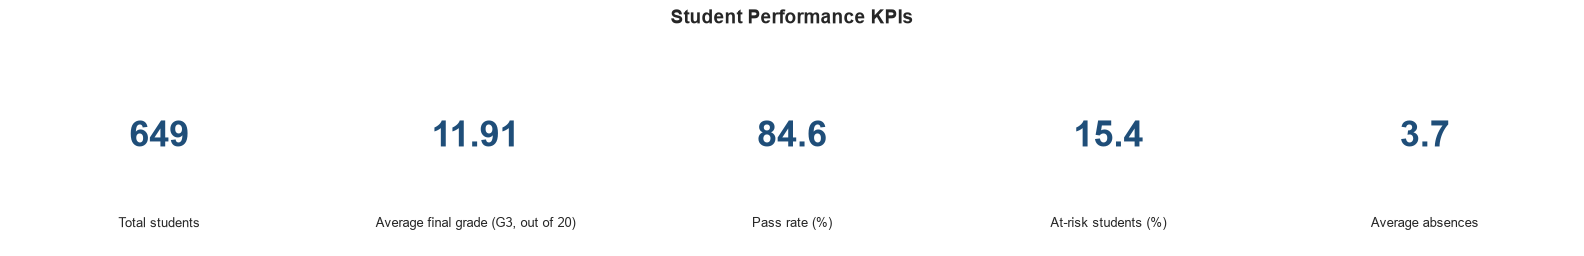

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(16, 2.6))
for ax, (k, v) in zip(axes, kpis.items()):
    ax.axis("off")
    ax.text(0.5, 0.58, str(v), ha="center", va="center", fontsize=26, fontweight="bold", color="#1f4e79")
    ax.text(0.5, 0.12, k, ha="center", va="center", fontsize=9, wrap=True)
plt.suptitle("Student Performance KPIs", fontsize=14, fontweight="bold")
save("01_kpis")

## 4. Trends: How Are Grades Distributed?

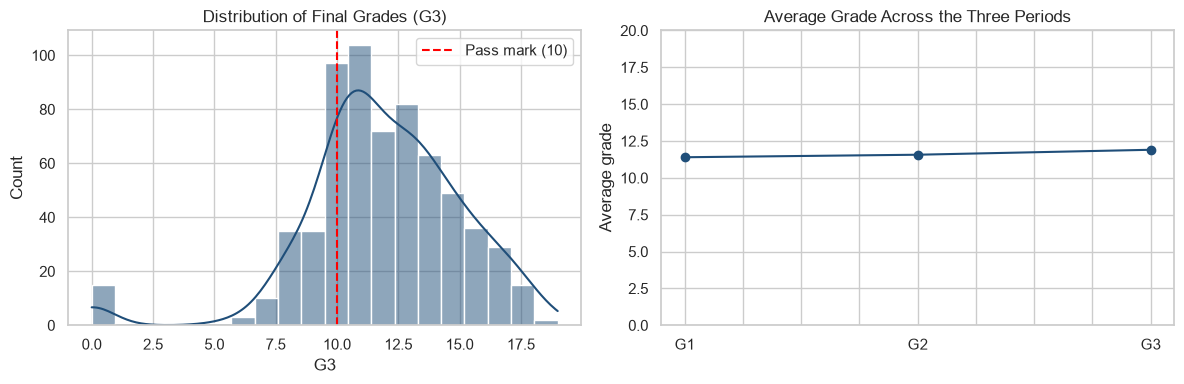

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["G3"], bins=20, kde=True, ax=axes[0], color="#1f4e79")
axes[0].axvline(10, color="red", linestyle="--", label="Pass mark (10)")
axes[0].set_title("Distribution of Final Grades (G3)")
axes[0].legend()

df[["G1", "G2", "G3"]].mean().plot(kind="line", marker="o", ax=axes[1], color="#1f4e79")
axes[1].set_title("Average Grade Across the Three Periods")
axes[1].set_ylabel("Average grade")
axes[1].set_ylim(0, 20)
save("02_grade_trends")

## 5. Drivers: What Influences the Final Grade?

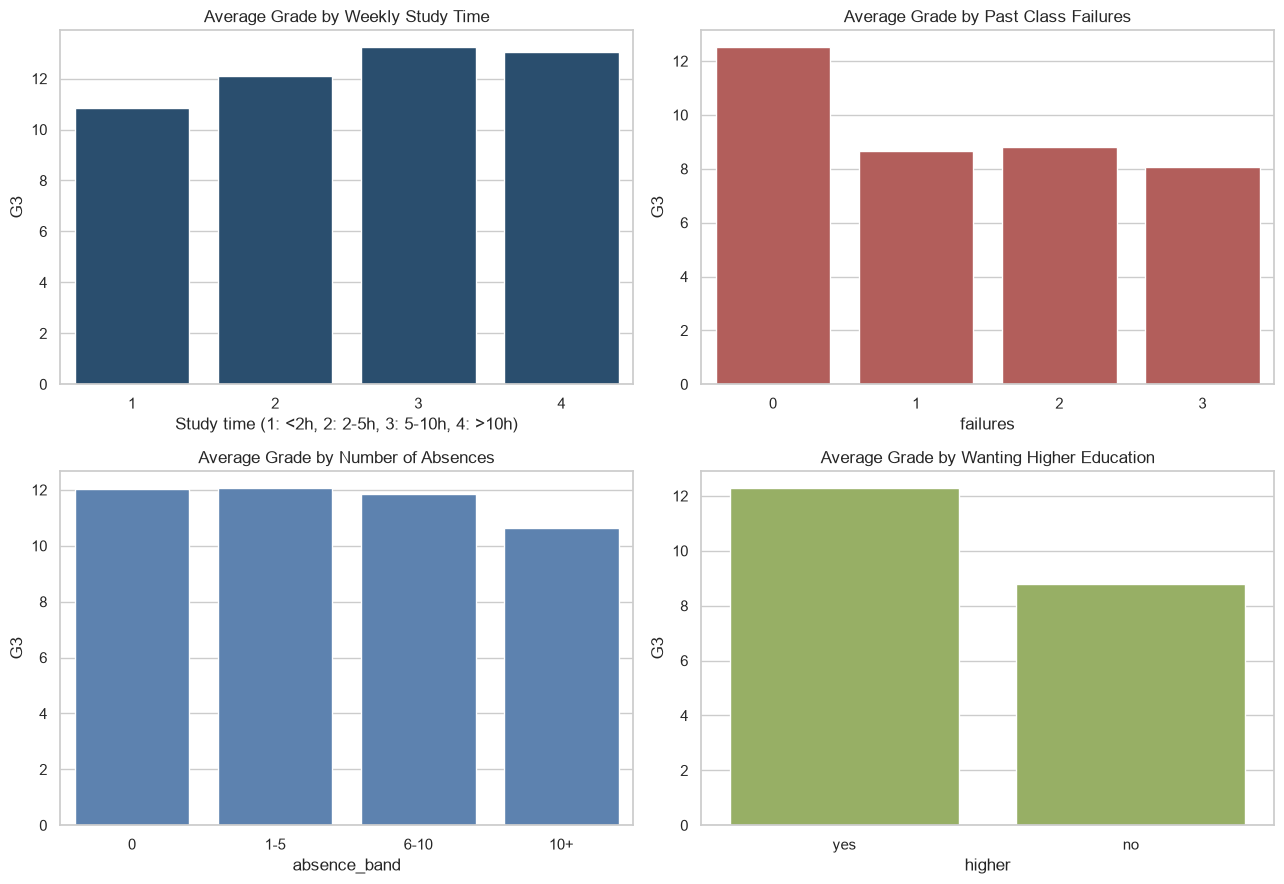

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.barplot(data=df, x="studytime", y="G3", ax=axes[0, 0], color="#1f4e79", errorbar=None)
axes[0, 0].set_title("Average Grade by Weekly Study Time")
axes[0, 0].set_xlabel("Study time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)")

sns.barplot(data=df, x="failures", y="G3", ax=axes[0, 1], color="#c0504d", errorbar=None)
axes[0, 1].set_title("Average Grade by Past Class Failures")

sns.barplot(data=df, x="absence_band", y="G3", ax=axes[1, 0], color="#4f81bd", errorbar=None)
axes[1, 0].set_title("Average Grade by Number of Absences")

sns.barplot(data=df, x="higher", y="G3", ax=axes[1, 1], color="#9bbb59", errorbar=None)
axes[1, 1].set_title("Average Grade by Wanting Higher Education")
save("03_grade_drivers")

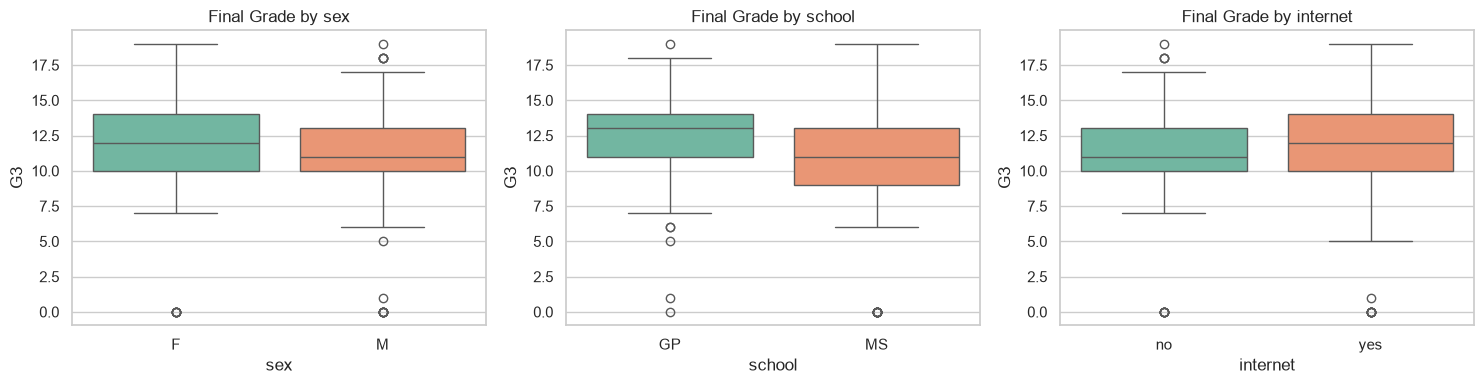

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["sex", "school", "internet"]):
    sns.boxplot(data=df, x=col, y="G3", ax=ax, palette="Set2")
    ax.set_title(f"Final Grade by {col}")
save("04_group_comparison")

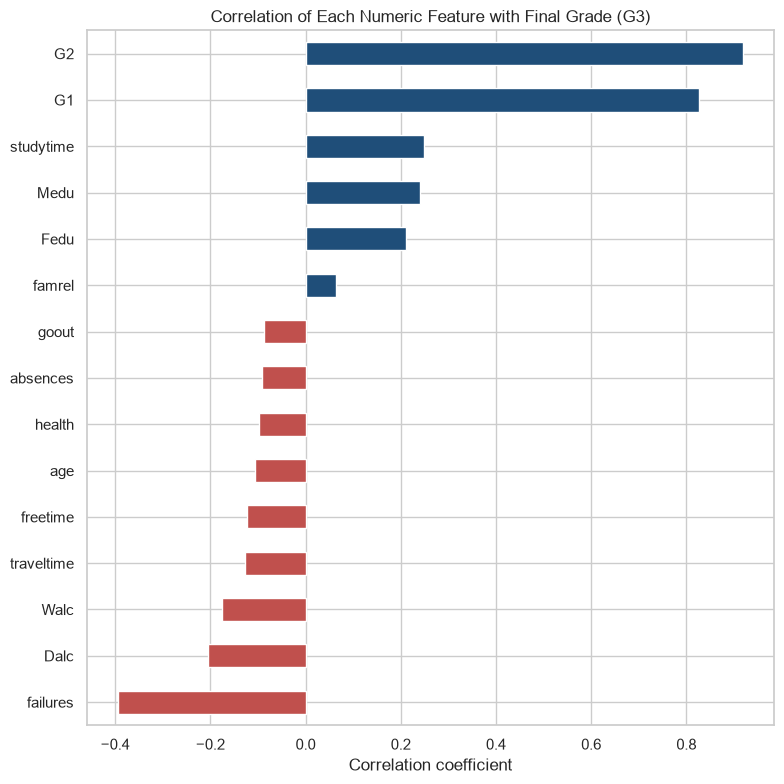

G2           0.92
G1           0.83
studytime    0.25
Medu         0.24
Fedu         0.21
famrel       0.06
absences    -0.09
goout       -0.09
Name: G3, dtype: float64

In [11]:
num = df.select_dtypes(include="number").drop(columns=["pass_fail", "at_risk"])
corr = num.corr()["G3"].drop("G3").sort_values()

plt.figure(figsize=(8, 8))
colors = ["#c0504d" if v < 0 else "#1f4e79" for v in corr.values]
corr.plot(kind="barh", color=colors)
plt.title("Correlation of Each Numeric Feature with Final Grade (G3)")
plt.xlabel("Correlation coefficient")
save("05_correlation_with_g3")
corr.round(2).sort_values(ascending=False).head(8)

**Observation:** Earlier period grades (`G1`, `G2`) are by far the strongest signals. Among non-grade factors, past failures, age and parental education show the clearest relationship with `G3`.

## 6. Risk Analysis: Which Students Are Most at Risk?

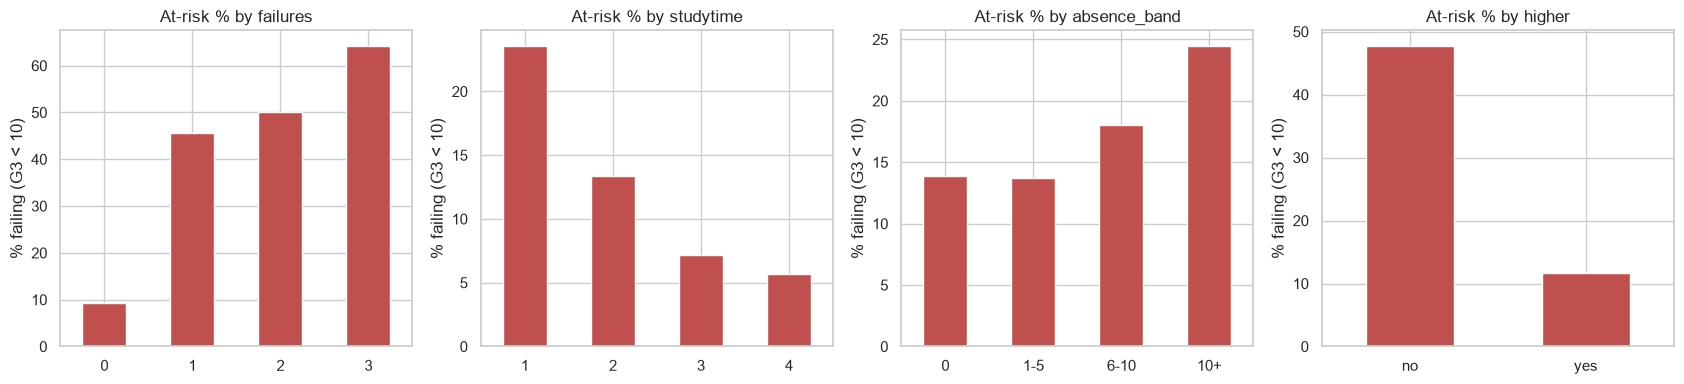

,At-risk % by past failures
failures,
0,9.3
1,45.7
2,50.0
3,64.3


In [12]:
risk_tables = {}
for col in ["failures", "studytime", "absence_band", "higher"]:
    risk_tables[col] = (df.groupby(col, observed=True)["at_risk"].mean() * 100).round(1)

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, (col, s) in zip(axes, risk_tables.items()):
    s.plot(kind="bar", ax=ax, color="#c0504d")
    ax.set_title(f"At-risk % by {col}")
    ax.set_ylabel("% failing (G3 < 10)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
save("06_risk_analysis")
pd.DataFrame(risk_tables["failures"]).rename(columns={"at_risk": "At-risk % by past failures"})

## 7. Prediction Model
We predict the final grade `G3` using Machine Learning. Two setups are compared:

| Setup | Features used | Purpose |
|---|---|---|
| **A. Full model** | All features including `G1`, `G2` | Best accuracy, available late in the year |
| **B. Early-warning model** | Everything **except** `G1`, `G2` | Usable at the start of the year, when it is most useful for intervention |

Models: **Linear Regression** (baseline) and **Random Forest** (non-linear).

In [13]:
target = "G3"
drop_cols = ["G3", "pass_fail", "at_risk", "absence_band"]

def prepare(exclude_grades):
    cols_to_drop = drop_cols + (["G1", "G2"] if exclude_grades else [])
    X = pd.get_dummies(df.drop(columns=cols_to_drop), drop_first=True)
    y = df[target]
    return X, y

def evaluate(exclude_grades):
    X, y = prepare(exclude_grades)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    }
    rows, fitted = [], {}
    for name, m in models.items():
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
        rows.append({
            "Model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred),
        })
        fitted[name] = m
    return pd.DataFrame(rows).round(3), fitted, X, X_test, y_test

res_full, models_full, X_full, Xt_full, yt_full = evaluate(exclude_grades=False)
res_early, models_early, X_early, Xt_early, yt_early = evaluate(exclude_grades=True)

print("A. Full model (with G1, G2)")
display(res_full)
print("B. Early-warning model (without G1, G2)")
display(res_early)

A. Full model (with G1, G2)


,Model,MAE,RMSE,R2
0,Linear Regression,0.765,1.215,0.849
1,Random Forest,0.751,1.247,0.841


B. Early-warning model (without G1, G2)


,Model,MAE,RMSE,R2
0,Linear Regression,2.156,2.862,0.160
1,Random Forest,2.057,2.820,0.185


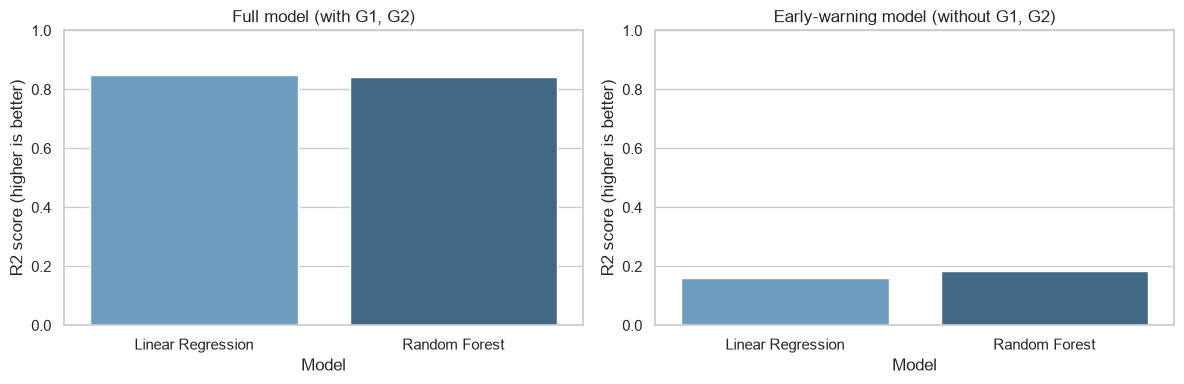

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, res) in zip(axes, [("Full model (with G1, G2)", res_full),
                                    ("Early-warning model (without G1, G2)", res_early)]):
    sns.barplot(data=res, x="Model", y="R2", ax=ax, palette="Blues_d")
    ax.set_title(title)
    ax.set_ylabel("R2 score (higher is better)")
    ax.set_ylim(min(0, res["R2"].min() - 0.1), 1)
save("07_model_comparison")

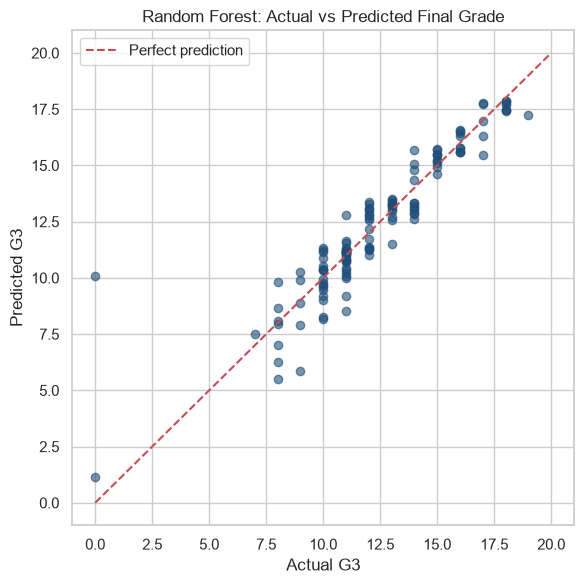

In [15]:
# Actual vs predicted for the best full model
best = models_full["Random Forest"]
pred = best.predict(Xt_full)

plt.figure(figsize=(6, 6))
plt.scatter(yt_full, pred, alpha=0.6, color="#1f4e79")
plt.plot([0, 20], [0, 20], "r--", label="Perfect prediction")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Random Forest: Actual vs Predicted Final Grade")
plt.legend()
save("08_actual_vs_predicted")

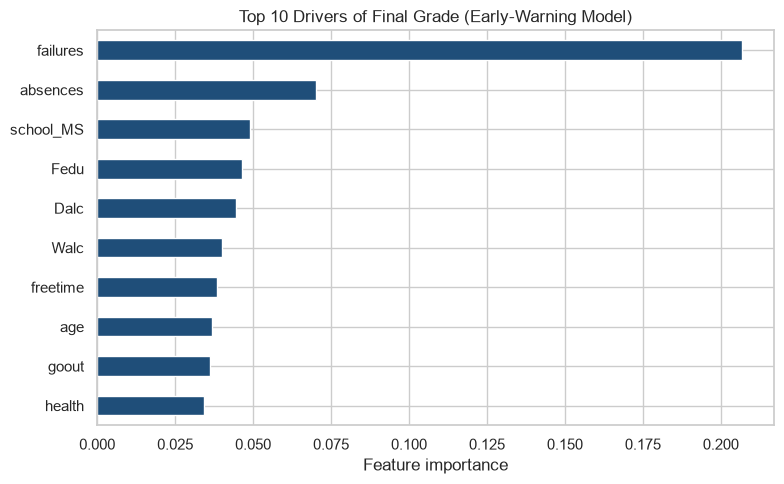

failures     0.207
absences     0.070
school_MS    0.049
Fedu         0.046
Dalc         0.045
Walc         0.040
freetime     0.038
age          0.037
goout        0.036
health       0.034
dtype: float64

In [16]:
# What matters most when grades G1/G2 are NOT available?
rf_early = models_early["Random Forest"]
imp = pd.Series(rf_early.feature_importances_, index=X_early.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
imp[::-1].plot(kind="barh", color="#1f4e79")
plt.title("Top 10 Drivers of Final Grade (Early-Warning Model)")
plt.xlabel("Feature importance")
save("09_feature_importance")
imp.round(3)

In [17]:
# Cross-validation to check the model is stable
X, y = prepare(exclude_grades=False)
cv = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=42), X, y, cv=5, scoring="r2")
print("Full model 5-fold CV R2:", cv.round(3), "| mean =", round(cv.mean(), 3))

Full model 5-fold CV R2: [0.752 0.699 0.826 0.831 0.79 ] | mean = 0.78


## 8. Insights: Risks, Opportunities and Actions

In [18]:
fail_risk = df.groupby(df["failures"] > 0)["at_risk"].mean() * 100
study_low = df[df["studytime"] == 1]["at_risk"].mean() * 100
study_high = df[df["studytime"] >= 3]["at_risk"].mean() * 100
abs_high = df[df["absences"] > 10]["at_risk"].mean() * 100
abs_low = df[df["absences"] <= 5]["at_risk"].mean() * 100
higher_no = df[df["higher"] == "no"]["at_risk"].mean() * 100
higher_yes = df[df["higher"] == "yes"]["at_risk"].mean() * 100
best_full = res_full.sort_values("R2", ascending=False).iloc[0]
best_early = res_early.sort_values("R2", ascending=False).iloc[0]

print("RISKS")
print(f"- Students with past failures fail {fail_risk.get(True, float('nan')):.1f}% of the time vs {fail_risk.get(False, float('nan')):.1f}% for those without.")
print(f"- Students with <2h weekly study fail {study_low:.1f}% vs {study_high:.1f}% for those studying 5h+.")
print(f"- Students with 10+ absences fail {abs_high:.1f}% vs {abs_low:.1f}% for those with up to 5.")
print()
print("OPPORTUNITIES")
print(f"- Students not planning higher education fail {higher_no:.1f}% vs {higher_yes:.1f}% for those who do: motivation and counselling matter.")
print(f"- The best full model ({best_full['Model']}) reaches R2 = {best_full['R2']:.2f}, MAE = {best_full['MAE']:.2f} grade points.")
print(f"- Even without G1/G2, the early-warning model ({best_early['Model']}) reaches R2 = {best_early['R2']:.2f}.")

RISKS
- Students with past failures fail 49.0% of the time vs 9.3% for those without.
- Students with <2h weekly study fail 23.6% vs 6.8% for those studying 5h+.
- Students with 10+ absences fail 24.5% vs 13.8% for those with up to 5.

OPPORTUNITIES
- Students not planning higher education fail 47.8% vs 11.6% for those who do: motivation and counselling matter.
- The best full model (Linear Regression) reaches R2 = 0.85, MAE = 0.77 grade points.
- Even without G1/G2, the early-warning model (Random Forest) reaches R2 = 0.18.


### Recommended Actions
1. **Early-warning programme:** flag students with past failures or low study time in the first weeks of the year. Use the model only as a supporting screening tool.
2. **Attendance monitoring:** trigger a parent/teacher conversation when a student crosses about 10 absences.
3. **Targeted tutoring:** offer extra classes to students with past failures, the highest-risk group.
4. **Motivation and career counselling:** support students who do not plan to pursue higher education.
5. **Use G1/G2 checkpoints:** the first two period grades are the strongest predictors, so intervene right after G1 rather than waiting for G3.

## 9. Conclusion and Limitations
**Conclusion:** Final grades can be predicted well once earlier grades (G1, G2) are known (R² = 0.85, average error about 0.77 grade points). Without them, prediction is much weaker (R² = 0.18), so the model works only as a screening aid. The clearest, actionable drivers are past failures, study time, absences and intention to pursue higher education.

**Limitations:**
- Small dataset (649 students from two Portuguese schools), so results may not generalise elsewhere.
- Correlation is not causation: the model shows association, not proof that changing a factor changes the grade.
- The model should support teachers' judgement, not replace it.

**Future work:** add the Portuguese-course dataset, try gradient boosting, and build an interactive dashboard.